# Exploratory Data Analysis (EDA)

## Purpose
Examines the structure, distribution, and temporal patterns of the champagne sales training data. The goal is to identify key characteristics — trend, seasonality, variance behaviour — that will inform modelling decisions downstream.

## Inputs
- `data/dataset.csv` — Training dataset (93 monthly observations)

## Outputs
- All outputs are visual and descriptive statistics.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

## Load Training Data

Load the training series from CSV with a parsed `DatetimeIndex`. `.head()` provides a quick sanity check on the index format and value range.

In [8]:
series = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Descriptive Statistics

`describe()` surfaces count, mean, standard deviation, and percentiles. This gives an immediate sense of the sales magnitude and spread — useful for detecting anomalies and for later interpreting model error metrics.

In [3]:
series.describe()

count       93.000000
mean      4641.118280
std       2486.403841
min       1573.000000
25%       3036.000000
50%       4016.000000
75%       5048.000000
max      13916.000000
Name: Sales, dtype: float64

## Time Series Line Plot

A simple line plot over the full training period. Look for an upward/downward trend, seasonal cycles, and any structural breaks or outliers.

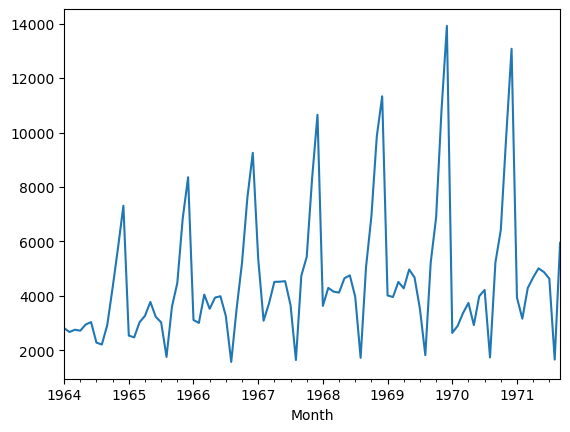

In [4]:
series.plot();

## Seasonal Subseries Plots

Plot each year's monthly observations in its own subplot. This layout makes it easy to compare the shape of the seasonal cycle year-over-year and to assess whether the pattern is stable or evolving.

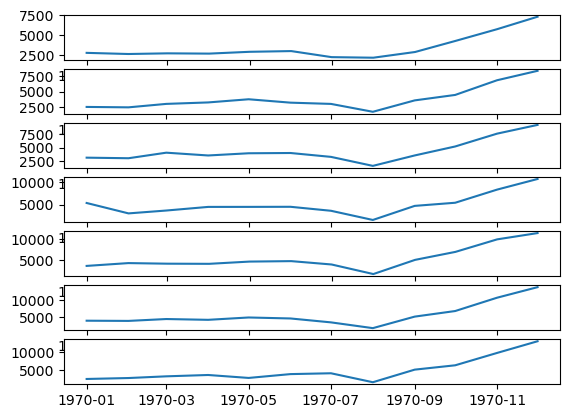

In [5]:
groups = series['1964':'1970'].groupby(pd.Grouper(freq='YE'))
plt.figure();
i = 1
n_groups = len(groups)
for name, group in groups:
    plt.subplot((n_groups*100) + 10 + i)
    i += 1
    plt.plot(group)

## Distribution Plots

A histogram paired with a kernel density estimate (KDE) reveals the overall distribution of sales values. Skewness or multi-modality here can indicate the need for a variance-stabilising transformation before modelling.

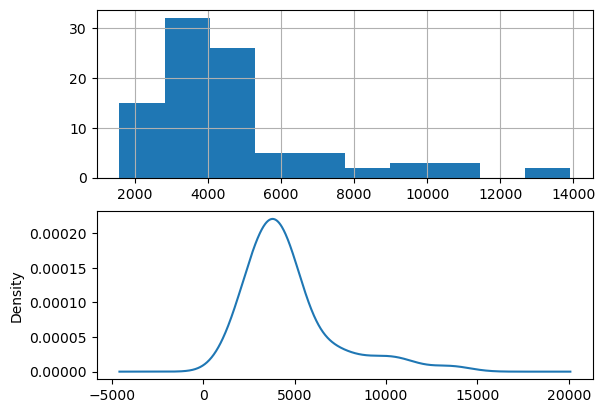

In [6]:
plt.figure(1);
plt.subplot(211);
series.hist();
plt.subplot(212);
series.plot(kind='kde');

## Annual Box Plots

Box plots grouped by year highlight changes in median and spread over time. Growing variance with increasing level is a hallmark of multiplicative seasonality and would suggest a log transform is appropriate.

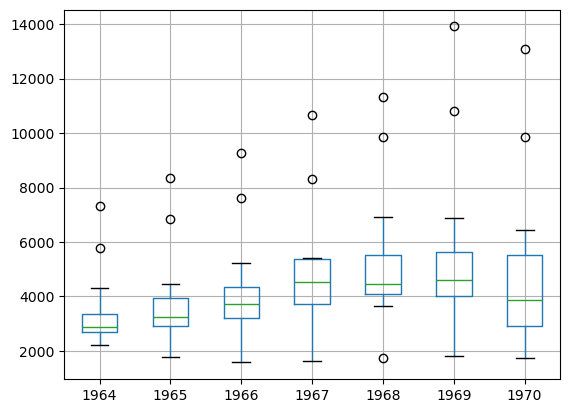

In [7]:
groups = series['1964':'1970'].groupby(pd.Grouper(freq='YE'))
years = pd.DataFrame()
for name, group in groups:
    years[name.year] = group.values
years.boxplot();